# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [9]:
# TODO
print(f"Kich thuoc du lieu gom {df.shape[0]} dong va {df.shape[1]} cot")
print("Column name:", df.columns.tolist())
print("Kieu du lieu tung cot la:\n",df.dtypes)

Kich thuoc du lieu gom 1338 dong va 7 cot
Column name: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Kieu du lieu tung cot la:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


## A.2. Missing values & Duplicate data

In [13]:
# TODO
display(df.isnull())
display(df.duplicated())


,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

## A.3. Invalid values

In [14]:
# TODO

print(df[df['age'] <= 0])

print(df[df['bmi'] <= 0])

print(df[df['children'] < 0])

print(df[df['charges'] < 0])

print(df['sex'].unique())

print(df['smoker'].unique())

print(df['region'].unique())

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [17]:
# TODO
df['bmi_group'] = np.select(
    [
        df['bmi'] < 25,
        (df['bmi'] >= 25) & (df['bmi'] < 30),
        df['bmi'] >= 30
    ],
    [
        'Normal',
        'Overweight',
        'Obese'
    ],
    default='Unknown'
)

print(df[['bmi', 'bmi_group']].head(10))

      bmi   bmi_group
0  27.900  Overweight
1  33.770       Obese
2  33.000       Obese
3  22.705      Normal
4  28.880  Overweight
5  25.740  Overweight
6  33.440       Obese
7  27.740  Overweight
8  29.830  Overweight
9  25.840  Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [18]:
# TODO

print("Mean:")
print(df[['age', 'bmi', 'children', 'charges']].mean())

print("\nMedian:")
print(df[['age', 'bmi', 'children', 'charges']].median())

print("\nMode:")
print(df[['age', 'bmi', 'children', 'charges']].mode().iloc[0])

Mean:
age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64

Median:
age           39.000
bmi           30.400
children       1.000
charges     9382.033
dtype: float64

Mode:
age           18.0000
bmi           32.3000
children       0.0000
charges     1639.5631
Name: 0, dtype: float64


## Group 2 — Dispersion

In [19]:
# TODO
print(df[['age', 'bmi', 'children', 'charges']].var())

print(df[['age', 'bmi', 'children', 'charges']].std())

print(df[['age', 'bmi', 'children', 'charges']].min())

print(df[['age', 'bmi', 'children', 'charges']].max())

print(
    df[['age', 'bmi', 'children', 'charges']].max()
    - df[['age', 'bmi', 'children', 'charges']].min()
)

age         1.974014e+02
bmi         3.718788e+01
children    1.453213e+00
charges     1.466524e+08
dtype: float64
age            14.049960
bmi             6.098187
children        1.205493
charges     12110.011237
dtype: float64
age           18.0000
bmi           15.9600
children       0.0000
charges     1121.8739
dtype: float64
age            64.00000
bmi            53.13000
children        5.00000
charges     63770.42801
dtype: float64
age            46.00000
bmi            37.17000
children        5.00000
charges     62648.55411
dtype: float64


## Group 3 — Location and Shape

In [20]:
# TODO
print("Quartiles:")
print(df[['age', 'bmi', 'children', 'charges']].quantile([0.25, 0.5, 0.75]))

Q1 = df[['age', 'bmi', 'children', 'charges']].quantile(0.25)
Q3 = df[['age', 'bmi', 'children', 'charges']].quantile(0.75)

IQR = Q3 - Q1

print("\nIQR:")
print(IQR)

print("\nSkewness:")
print(df[['age', 'bmi', 'children', 'charges']].skew())

print("\nKurtosis:")
print(df[['age', 'bmi', 'children', 'charges']].kurt())

Quartiles:
       age       bmi  children       charges
0.25  27.0  26.29625       0.0   4740.287150
0.50  39.0  30.40000       1.0   9382.033000
0.75  51.0  34.69375       2.0  16639.912515

IQR:
age            24.000000
bmi             8.397500
children        2.000000
charges     11899.625365
dtype: float64

Skewness:
age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

Kurtosis:
age        -1.245088
bmi        -0.050732
children    0.202454
charges     1.606299
dtype: float64


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [21]:
# TODO
smoker_cost = df.groupby('smoker')['charges'].mean()

print("Chi phí trung bình:")
print(smoker_cost)

ratio = smoker_cost['yes'] / smoker_cost['no']

print("\nNgười hút thuốc trả cao hơn khoảng:",
      round(ratio, 2), "lần")

region_smoker = df.pivot_table(
    values='charges',
    index='region',
    columns='smoker',
    aggfunc='mean'
)

print("\nChi phí trung bình theo vùng và tình trạng hút thuốc:")
print(region_smoker)


region_smoker['ratio'] = (
    region_smoker['yes'] / region_smoker['no']
)

print("\nTỷ lệ smoker / non-smoker theo vùng:")
print(region_smoker['ratio'])

Chi phí trung bình:
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Người hút thuốc trả cao hơn khoảng: 3.8 lần

Chi phí trung bình theo vùng và tình trạng hút thuốc:
smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8556.463715  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494

Tỷ lệ smoker / non-smoker theo vùng:
region
northeast    3.237514
northwest    3.528561
southeast    4.338155
southwest    4.023933
Name: ratio, dtype: float64


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [22]:
# TODO
corr_smoker = df[df['smoker'] == 'yes']['bmi'].corr(
    df[df['smoker'] == 'yes']['charges']
)

corr_non_smoker = df[df['smoker'] == 'no']['bmi'].corr(
    df[df['smoker'] == 'no']['charges']
)

print("Tương quan BMI - Charges")

print("Nhóm hút thuốc:", round(corr_smoker, 4))
print("Nhóm không hút thuốc:", round(corr_non_smoker, 4))

if abs(corr_smoker) > abs(corr_non_smoker):
    print("\n=> BMI tương quan mạnh hơn với charges ở nhóm hút thuốc.")
else:
    print("\n=> BMI tương quan mạnh hơn với charges ở nhóm không hút thuốc.")

Tương quan BMI - Charges
Nhóm hút thuốc: 0.8065
Nhóm không hút thuốc: 0.084

=> BMI tương quan mạnh hơn với charges ở nhóm hút thuốc.


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

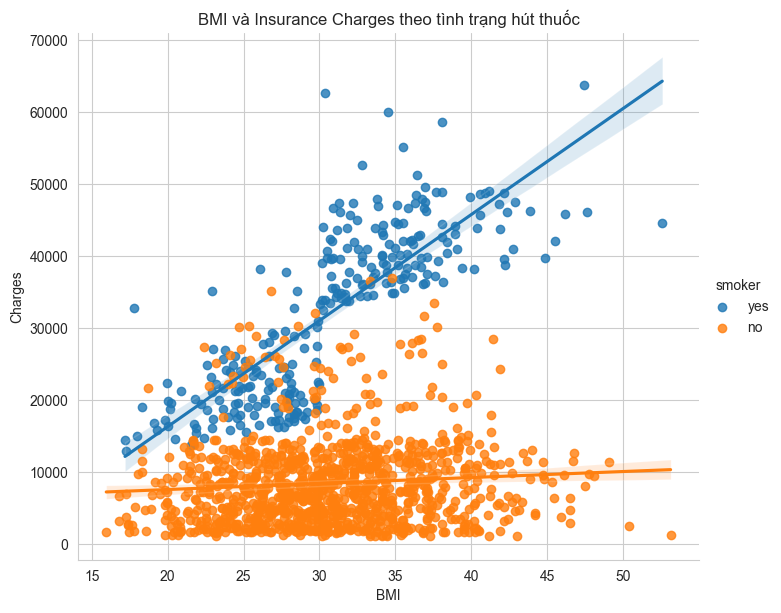

In [23]:
# TODO
sns.lmplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker',
    height=6,
    aspect=1.2
)

plt.title('BMI và Insurance Charges theo tình trạng hút thuốc')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [24]:
# TODO
region_cost = df.groupby('region')['charges'].mean().sort_values(
    ascending=False
)

print("Chi phí bảo hiểm trung bình theo vùng:")
print(region_cost)

highest_region = region_cost.idxmax()
highest_cost = region_cost.max()

print(
    f"\n=> Vùng có chi phí bảo hiểm trung bình cao nhất: "
    f"{highest_region}"
)

print(
    f"=> Chi phí trung bình: {highest_cost:.2f}"
)

Chi phí bảo hiểm trung bình theo vùng:
region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

=> Vùng có chi phí bảo hiểm trung bình cao nhất: southeast
=> Chi phí trung bình: 14735.41


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [25]:
# TODO
children_cost = df.groupby('children')['charges'].mean()

print("Chi phí bảo hiểm trung bình theo số con:")
print(children_cost)

corr_children = df['children'].corr(df['charges'])

print(
    "\nHệ số tương quan giữa số con và chi phí:",
    round(corr_children, 4)
)



Chi phí bảo hiểm trung bình theo số con:
children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

Hệ số tương quan giữa số con và chi phí: 0.068


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*